# 📊 Sales Data Analysis using SQL and Python
## Project Overview
This project analyzes a retail sales dataset using SQL for aggregation and Python (Pandas, Matplotlib, Seaborn) for visualization.

### Objectives:
- Analyze regional sales performance
- Evaluate profitability by category and sub-category
- Examine customer segment contribution
- Study the impact of discounts on profit

---
## 🛠 Tools & Technologies Used
- Python (Pandas, Matplotlib, Seaborn)
- SQL (SQLite)
- Jupyter Notebook

## 📂 Data Loading
The dataset was imported from Kaggle and loaded into a Pandas DataFrame for analysis.

In [1]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("SampleSuperStore.csv")
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


## 🧹 Data Preprocessing
Before performing analysis, the dataset was examined and prepared:

- Checked data types using `df.info()`
- Generated summary statistics using `df.describe()`
- Verified absence of missing values using `df.isnull().sum()`
- Checked for duplicate records
- Standardized column names for SQL compatibility

The dataset did not contain missing or duplicate values, so minimal cleaning was required before loading into the SQL database.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [4]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.857901,3.789574,0.156203,28.656599
std,32063.693350,623.245124,2.225110,0.206452,234.260115
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [5]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(17)

In [7]:
df.drop_duplicates()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.2480,3,0.20,4.1028
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.9600,2,0.00,15.6332
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.5760,2,0.20,19.3932
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.6000,4,0.00,13.3200


In [8]:
df.columns=df.columns.str.lower().str.replace(' ','_').str.replace('-','_')
df

,ship_mode,segment,country,city,state,postal_code,region,category,sub_category,sales,quantity,discount,profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.2480,3,0.20,4.1028
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.9600,2,0.00,15.6332
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.5760,2,0.20,19.3932
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.6000,4,0.00,13.3200


## 🗄️ Creating SQL Database
The dataset was stored in an SQLite database to perform SQL-based aggregation queries.

In [9]:
con=sqlite3.connect('Sales_Data.db')
df.to_sql('Sample_Super_Store',con,if_exists='replace',index=False,method='multi')

9994

In [10]:
df.head()

,ship_mode,segment,country,city,state,postal_code,region,category,sub_category,sales,quantity,discount,profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


# 📈 Exploratory Data Analysis
The following sections perform SQL-based aggregations and visualizations to extract key business insights.

## 🔎 1. Total Sales by Region
This analysis identifies which geographic region generates the highest total sales.

In [11]:
q1=""" SELECT region,sum(sales) as Total_Sales FROM Sample_Super_Store GROUP BY REGION """
v1=pd.read_sql(q1,con)
v1 = v1.sort_values("Total_Sales", ascending=False)
v1

,region,Total_Sales
3,West,725457.8245
1,East,678781.2400
0,Central,501239.8908
2,South,391720.9050


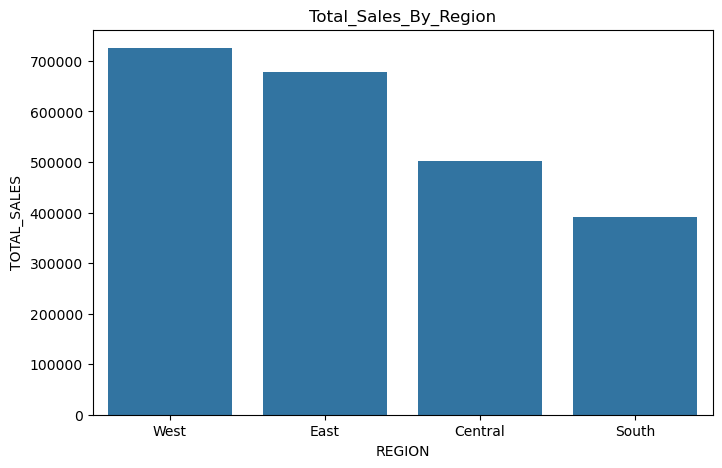

In [12]:
plt.figure(figsize=(8,5))
sns.barplot(x="region",y="Total_Sales",data=v1)
plt.xlabel("REGION")
plt.ylabel("TOTAL_SALES")
plt.title('Total_Sales_By_Region')
plt.show()

## 🔎 2. Total Profit by Category
This analysis evaluates overall profitability across product categories.

In [13]:
q2 = """SELECT category, SUM(profit) AS total_profit FROM Sample_Super_Store GROUP BY category ORDER BY total_profit DESC"""
v2 = pd.read_sql(q2, con)
v2

,category,total_profit
0,Technology,145451.9773
1,Office Supplies,122490.8008
2,Furniture,18451.2728


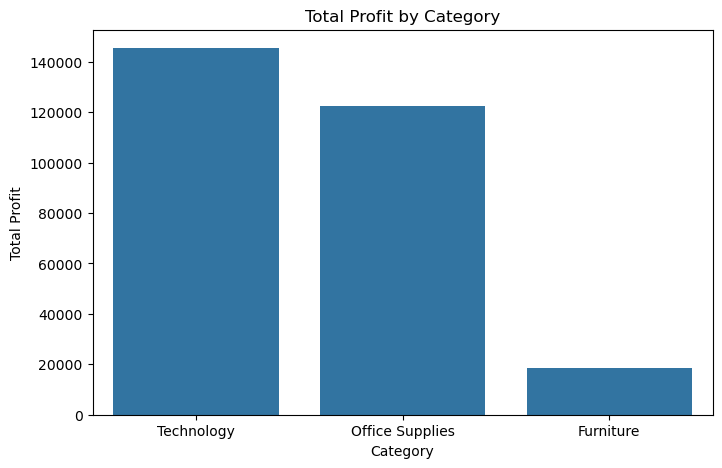

In [14]:
plt.figure(figsize=(8,5))
sns.barplot(x="category", y="total_profit", data=v2)
plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.show()

## 🔎 3. Total Sales by Customer Segment
This analysis examines which customer segment contributes the most to total revenue.

In [15]:
q3="""select segment,sum(sales) as Total_Sales from  Sample_Super_Store group by segment order by Total_Sales desc """
v3=pd.read_sql(q3,con)
v3

,segment,Total_Sales
0,Consumer,1.161400e+06
1,Corporate,7.061464e+05
2,Home Office,4.296531e+05


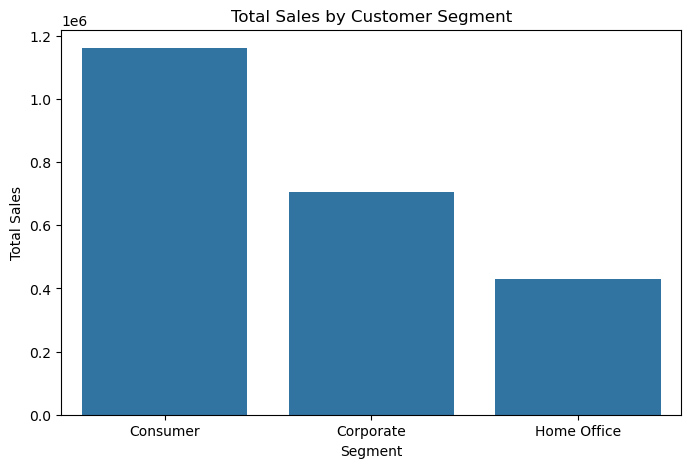

In [16]:
plt.figure(figsize=(8,5))
sns.barplot(x="segment", y="Total_Sales", data=v3)
plt.title("Total Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales")
plt.show()

## 🔎 4. Profit by Sub-Category
This analysis identifies which specific product sub-categories are driving profit or loss.

In [17]:
q4="SELECT sub_category, SUM(profit) AS total_profit FROM Sample_Super_Store GROUP BY sub_category ORDER BY total_profit ASC"
v4=pd.read_sql(q4,con)
v4.head(10)

,sub_category,total_profit
0,Tables,-17725.4811
1,Bookcases,-3472.5560
2,Supplies,-1189.0995
3,Fasteners,949.5182
4,Machines,3384.7569
5,Labels,5546.2540
6,Art,6527.7870
7,Envelopes,6964.1767
8,Furnishings,13059.1436
9,Appliances,18138.0054


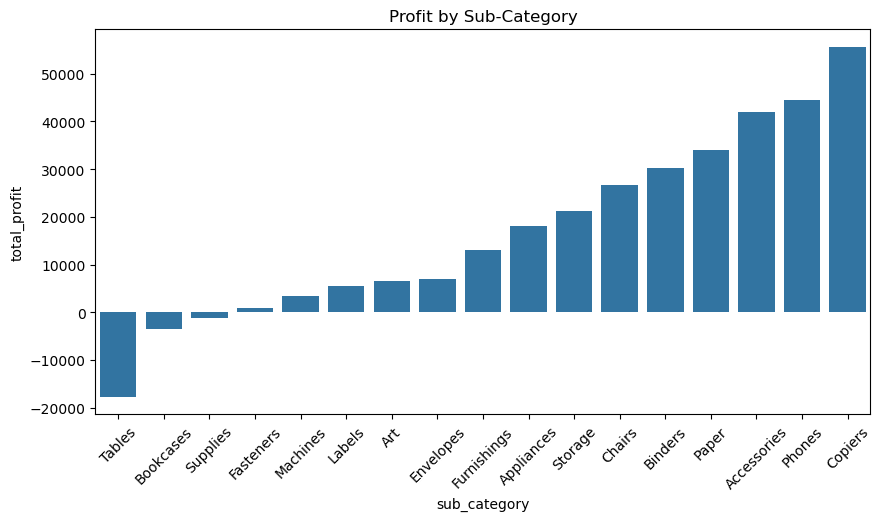

In [18]:
plt.figure(figsize=(10,5))
sns.barplot(x='sub_category',y='total_profit',data=v4)
plt.xticks(rotation=45)
plt.title('Profit by Sub-Category')
plt.xlabel('sub_category')
plt.ylabel('total_profit')
plt.show()

## 🔎 5. Impact of Discount on Profit
This analysis evaluates how discount levels influence profitability.

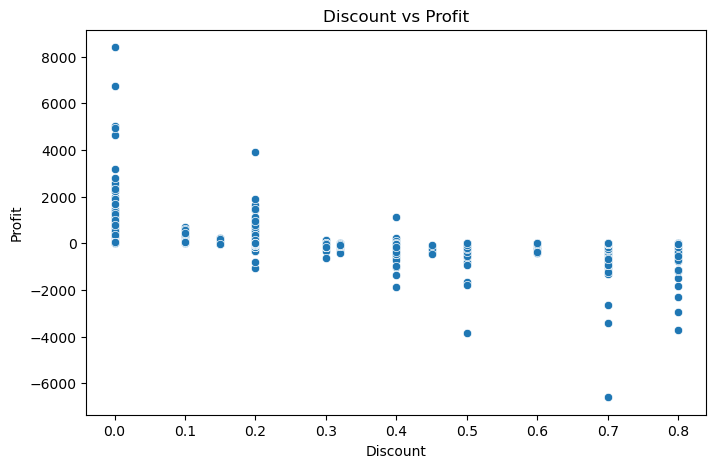

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='discount',y='profit',data=df)
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Discount vs Profit')
plt.show()

## 🔒 Closing Database Connection

After completing the analysis and visualizations, the SQLite database connection is safely closed to release system resources.

Properly closing the connection ensures:
- Efficient memory management
- No locked database files
- Clean execution workflow

In [20]:
con.close()

# 🏁 Final Conclusion
### Key Business Takeaways:
- West region dominates sales performance.
- Technology is the most profitable category.
- Consumer segment drives the majority of revenue.
- High discounting significantly reduces profitability.
- Certain sub-categories consistently generate losses.

This project demonstrates SQL aggregation, data analysis using Pandas, data visualization, and extraction of actionable business insights.